# ${}^{4}{\rm He}$

The interaction is defined in `helium4.py`. It is nonlocal, and so is the counterterm. We will use it to tune the scattering length, $a_0$, **and** the effective range, $r_0$, over a range of short-distance cutoffs, $R$.

In [1]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import scienceplots
from tqdm import tqdm

import helium4plusplusminus as he4
import lm2m2

plt.style.use('science')
gr = 4/3
h = 3

In [2]:
# angular momentum
ELL = 2

# load lo coupling constants
Rs, c00s, c01s, c21s, _, _ = np.loadtxt('datfiles/rg_flows/rg-nlo-physicalC6-2.txt', unpack=True)
# number of short distance cutoffs
nR = Rs.size

In [3]:
index = 0
R = Rs[index]
c00 = c00s[index]
c01 = c01s[index]
c21 = c21s[index]

s = he4.NonlocalHelium4System2(R, ELL, 2, 6, 6)

In [4]:
momenta = np.linspace(0.01/he4.BETA6, 0.3/he4.BETA6, 30)

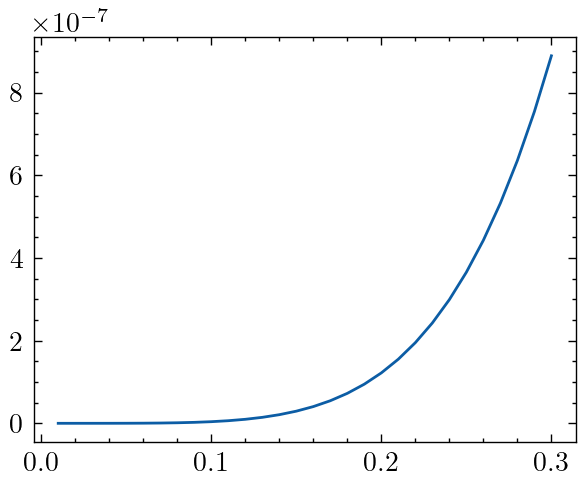

In [9]:
fig, ax = plt.subplots(dpi=200)
fig.patch.set_facecolor('white')

ax.plot(momenta * he4.BETA6, np.arctan(momenta**(2*ELL + 1)/ s.kcotd_gen_pert1_fast(momenta, c00 + c01, c21)));

In [12]:
for i in tqdm(range(nR)):
    R = Rs[i]
    c00 = c00s[i]
    c01 = c01s[i]
    c21 = c21s[i]
    s = he4.NonlocalHelium4System2(R, ELL, 2, 6, 6)
    deltas = np.arctan(momenta**(2*ELL + 1)/ s.kcotd_gen_pert1_fast(momenta, c00 + c01, c21))
    with open(f'datfiles/phase_shifts/nlo_d_wave/R_{R:.8e}_D_wave.txt', 'w+') as f:
        f.write('# momenta[i] (1/Å)  delta (rad)\n')
        for j in range(momenta.size):
            f.write(f'{momenta[j]}  {deltas[j]}\n')

100%|███████████████████████████████████████████| 67/67 [01:58<00:00,  1.77s/it]
